# 05 - Statistics & Exploring STATS19

Here I check out the STATS19 merged data and find out and visualise interesting trends about it

In [2]:
import pandas as pd
df = pd.read_csv('../data/STATS19/dft_STATS19_1979_23_SY.csv', low_memory=False)
print(df.shape)

# Show missing value counts
print(df.isnull().sum())
duplicates = df[df.duplicated(subset="accident_index", keep=False)]
print(f"Number of duplicate accident_index values: {len(duplicates)}")
print(df.size)
# Get the duplicate accident_reference values (the IDs that appear more than once)
duplicate_ids = df["accident_index"][df["accident_index"].duplicated()].unique()

# Filter rows with these duplicate accident_index values
# dupe_rows = df[df["accident_index"].isin(duplicate_ids)]

# Show the first 10 duplicates
# print(dupe_rows.sort_values("accident_index").head(10))

(243191, 85)
accident_index                  0
accident_year                   0
accident_reference              0
vehicle_reference               0
casualty_reference              0
                            ...  
dir_from_e                 237569
dir_from_n                 237569
dir_to_e                   237598
dir_to_n                   237598
driver_distance_banding         0
Length: 85, dtype: int64
Number of duplicate accident_index values: 103729
20671235


In [3]:
final_data = df
print(f"Final rows: {len(final_data)}")
print(f"Unique accidents: {final_data['accident_index'].nunique()}")
print(f"Unique casualties: {final_data['casualty_reference'].nunique()}")
print(f"Unique vehicles: {final_data['vehicle_reference'].nunique()}")


Final rows: 243191
Unique accidents: 180391
Unique casualties: 76
Unique vehicles: 20


In [16]:
import pandas as pd

# Step 1: Count how many rows (casualties) per accident
row_counts = df.groupby('accident_index').size()

# Step 2: Count how many accidents have N rows
accident_size_distribution = row_counts.value_counts().sort_index()

# # Convert to DataFrame for easier viewing
# asd = accident_size_distribution.reset_index()
# asd.columns = ['number_of_rows_per_accident', 'number_of_accidents']

# # Calculate total rows (accidents * rows)
# asd['total_rows'] = asd['number_of_rows_per_accident'] * asd['number_of_accidents']

# # Display DataFrame
# display(asd)

# # Optional: Display total row summary
# total_calculated_rows = asd['total_rows'].sum()
# print(f"\nTotal rows calculated: {total_calculated_rows:,}")
# print(f"Original DataFrame rows: {len(df):,}")


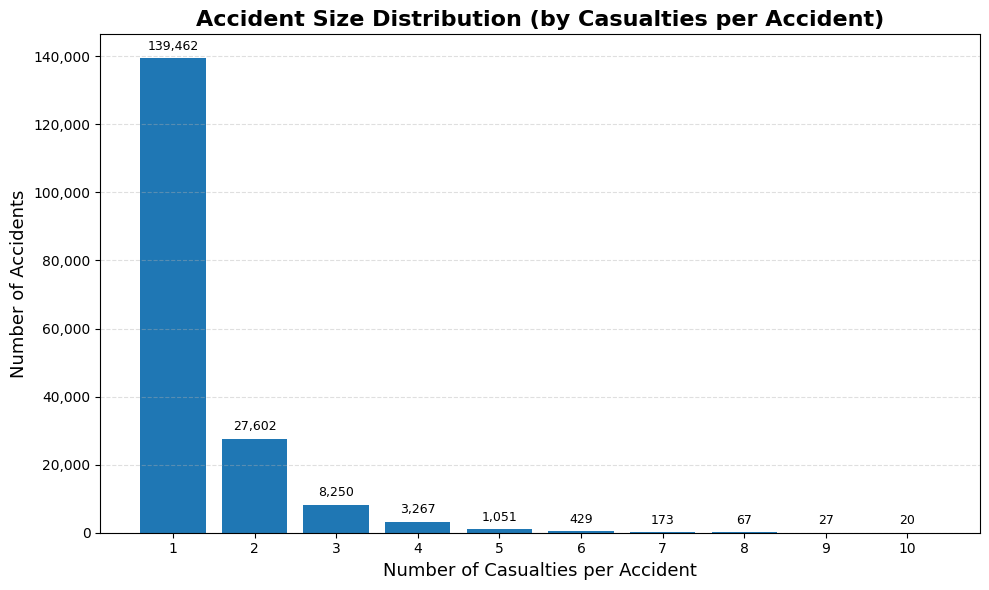

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# accident_size_distribution = asd['count']
# Trim to a reasonable max (e.g., accidents with up to 10 casualties)
filtered = accident_size_distribution[accident_size_distribution.index <= 10]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(filtered.index, filtered.values, color='#1f77b4')

# Title and labels
ax.set_title("Accident Size Distribution (by Casualties per Accident)", fontsize=16, weight='bold')
ax.set_xlabel("Number of Casualties per Accident", fontsize=13)
ax.set_ylabel("Number of Accidents", fontsize=13)

# Format y-axis numbers with commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add value labels only if count is meaningful
for bar in bars:
    height = bar.get_height()
    if height > 10:  # skip labeling tiny bars
        ax.annotate(f'{int(height):,}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

# Adjust ticks and layout
plt.xticks(filtered.index)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig("accident_size_distribution_cleaned.png", dpi=300)
plt.show()
